# Construct physically robust atmospheric background map

In [1]:
from pathlib import Path

# Import usual libraries
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import healpy as hp

from icecube_population_project.IceCube_expected_nu_counts import (
    MapMakerConfig,
    make_expected_counts_maps,
    poissonize_astro,
)
from icecube_population_project.IceCube_atmo_expected_counts import (
    AtmosphereConfig,
    make_atmo_expected_counts_maps,
    poissonize_atmo,
    combine_poisson_components,
)
from icecube_population_project.nu_pop_core import CosmologyGrid, SpectrumParams, PopulationParams, fz_sfr_md14

# Energy bin edges (GeV): 10 TeV -> 10 PeV
E_edges = np.logspace(4, 7, 6)

# Common output directory for simulated products
SIMS_ROOT = Path("/mnt/my-ssd/Data_for_IceCube_Population_Project/Sims")
SIMS_ROOT.mkdir(parents=True, exist_ok=True)



In [2]:
# ---------- Astrophysical component (upgraded: pre-PSF means + event-level PSF poissonization) ----------
astro_cfg = MapMakerConfig(
    dataset="20210126",
    period="IC86_II",
    aeff_units="m2",
    time_years=7.5,
    nside=512,
    psf_mode="irf_weighted_event",     # upgraded: event-level PSF only
    energy_bin_edges_GeV=E_edges,
    sources_to_draw=5000,
    scale_to_full_population=True,
    rng_seed_catalog=12345,
)

cosmo = CosmologyGrid()
spec  = SpectrumParams(gamma=2.2, Emin=1e4, Emax=1e7, L=1e42)  # L in erg/s (converted internally)
pop   = PopulationParams(n0=1e-7, fz_fn=lambda z: fz_sfr_md14(z))

astro_means = make_expected_counts_maps(spec, pop, cosmo, astro_cfg)


In [3]:
# ---------- Atmospheric component (already upgraded to event-level PSF) ----------
atm_cfg = AtmosphereConfig(
    dataset="20210126",
    period="IC86_II",
    aeff_units="m2",
    time_years=7.5,
    nside=512,
    energy_bin_edges_GeV=E_edges,
    conventional_model="honda2006",
    include_prompt=False,
    psf_mode="irf_weighted_event",     # upgraded: event-level PSF
    rng_seed=44,
)

atmo_means = make_atmo_expected_counts_maps(atm_cfg)

# Consistency checks with 04_data_to_maps_driver.ipynb scheme
assert np.allclose(E_edges, np.logspace(4, 7, 6)), "Energy binning mismatch"
assert astro_cfg.nside == 512 and atm_cfg.nside == 512, "nside mismatch"


In [4]:
# ---------- Poisson draws (now consistent: both go through event-level poissonizers) ----------
rng_seed = 42

astro_counts = poissonize_astro(astro_means, use_psf=True, rng_seed=rng_seed)
atmo_counts  = poissonize_atmo(atmo_means,  use_psf=True, rng_seed=rng_seed + 1)



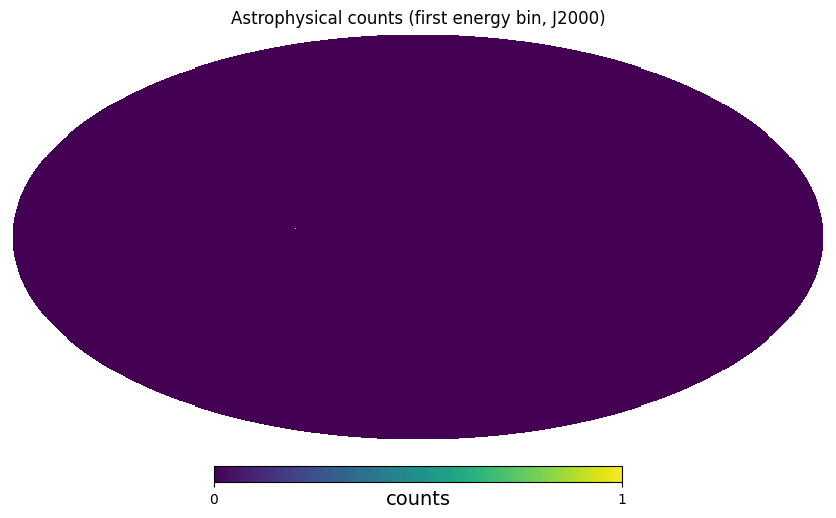

In [5]:
# ---------- Plots (first energy bin) ----------
hp.mollview(
    astro_counts["maps_counts"][0],
    title="Astrophysical counts (first energy bin, J2000)",
    unit="counts",
    flip="astro",
)


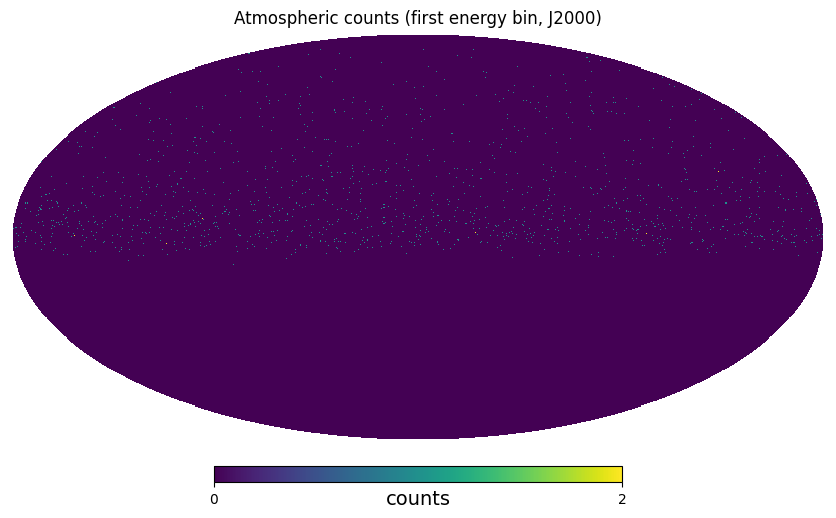

In [6]:
# ---------- Plots (first energy bin) ----------
hp.mollview(
    atmo_counts["maps_counts"][0],
    title="Atmospheric counts (first energy bin, J2000)",
    unit="counts",
    flip="astro",
)


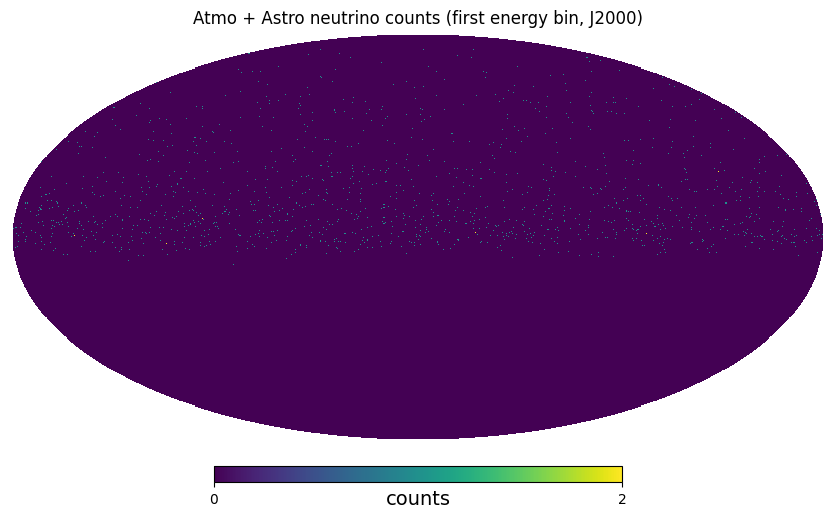

In [7]:
# ---------- Combined mock observation ----------
obs = combine_poisson_components(astro_counts, atmo_counts)

hp.mollview(
    obs["maps_counts"][0],
    title="Atmo + Astro neutrino counts (first energy bin, J2000)",
    unit="counts",
    flip="astro",
)


## Aitoff + declination histogram (same scheme as 04)

Side-by-side equatorial J2000 map and declination histogram for each energy bin, for visual comparison with `04_data_to_maps_driver.ipynb`.

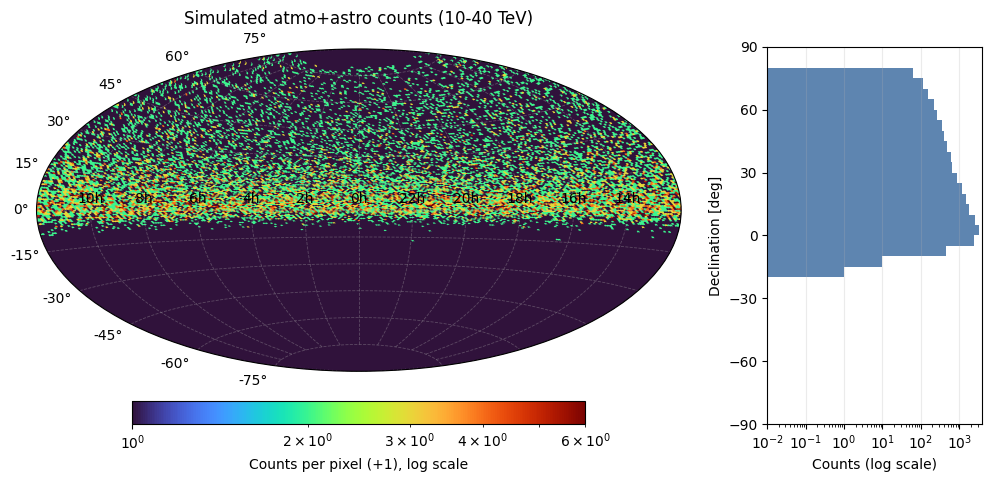

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/sim_atmo_astro_aitoff_dec_hist_bin00.png


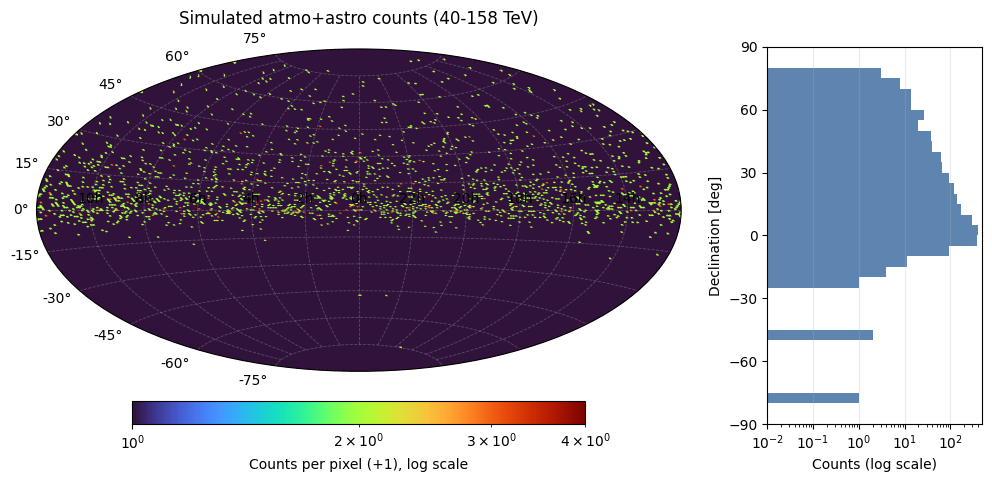

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/sim_atmo_astro_aitoff_dec_hist_bin01.png


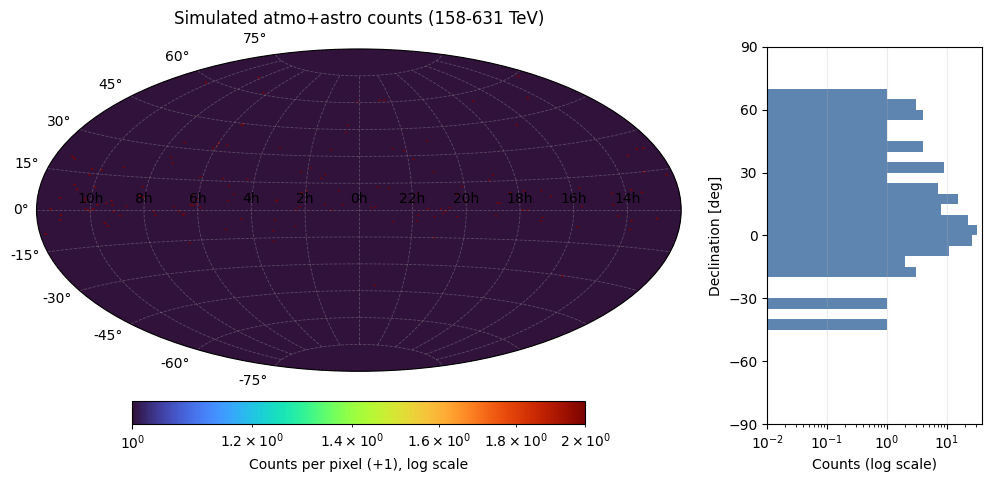

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/sim_atmo_astro_aitoff_dec_hist_bin02.png


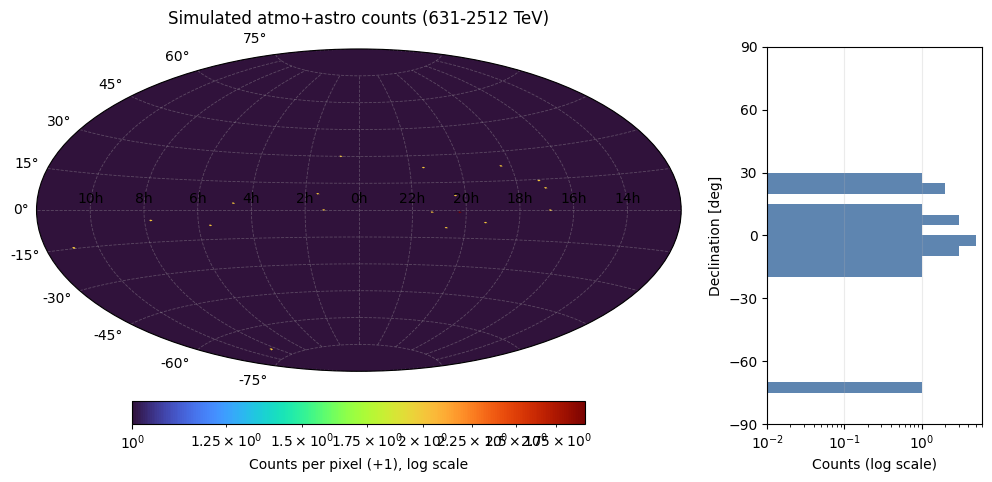

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/sim_atmo_astro_aitoff_dec_hist_bin03.png


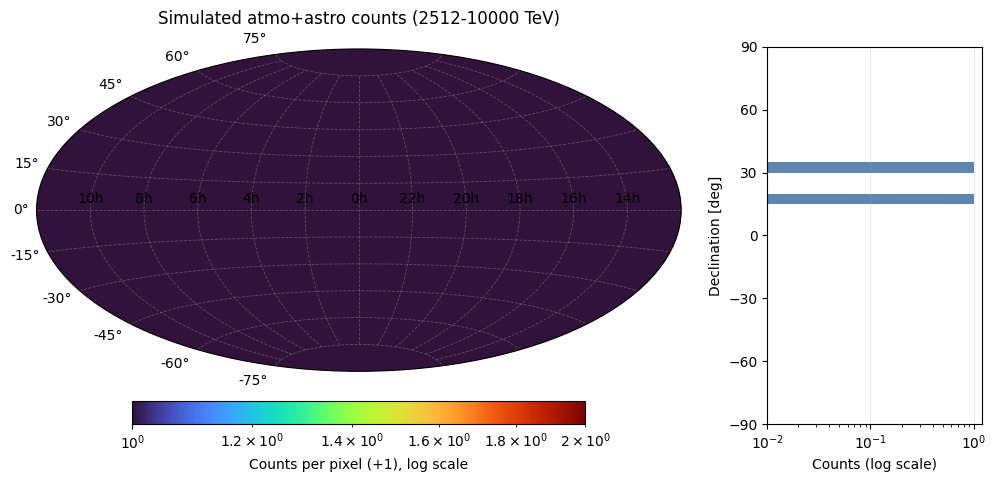

Saved figure: /mnt/my-ssd/Data_for_IceCube_Population_Project/Sims/sim_atmo_astro_aitoff_dec_hist_bin04.png
nside: 512 nest: False


In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import gridspec

counts_map = np.asarray(obs["maps_counts"], dtype=float)
E_edges_GeV = np.asarray(obs.get("bin_edges_GeV", E_edges), dtype=float)
nside_loaded = int(obs["nside"])
nest_loaded = bool(obs.get("nest", False))

order_in = "NEST" if nest_loaded else "RING"
nside_plot = min(64, nside_loaded)

npix_full = hp.nside2npix(nside_loaded)
theta_full, _ = hp.pix2ang(nside_loaded, np.arange(npix_full), nest=nest_loaded)
dec_full_deg = 90.0 - np.degrees(theta_full)
dec_bins = np.linspace(-90, 90, 37)
dec_centers = 0.5 * (dec_bins[:-1] + dec_bins[1:])
dec_heights = np.diff(dec_bins)

xticks = np.radians(np.array([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150]))
xticklabels = ["10h", "8h", "6h", "4h", "2h", "0h", "22h", "20h", "18h", "16h", "14h"]

plot_dir = SIMS_ROOT
plot_dir.mkdir(parents=True, exist_ok=True)

for i in range(counts_map.shape[0]):
    m_full = counts_map[i]
    counts_vs_dec, _ = np.histogram(dec_full_deg, bins=dec_bins, weights=m_full)

    m_plot = hp.ud_grade(
        m_full,
        nside_out=nside_plot,
        order_in=order_in,
        order_out="RING",
        power=-2,
    )

    npix_plot = hp.nside2npix(nside_plot)
    theta_plot, phi_plot = hp.pix2ang(nside_plot, np.arange(npix_plot), nest=False)
    dec_plot = 0.5 * np.pi - theta_plot
    ra_wrap = (phi_plot + np.pi) % (2 * np.pi) - np.pi
    lon_plot = -ra_wrap  # RA increasing to the left

    m_color = np.maximum(m_plot, 0.0) + 1.0
    positive = m_color[m_plot > 0]
    vmax = np.percentile(positive, 99.7) if positive.size > 0 else 2.0
    vmax = max(float(vmax), 2.0)

    e0_tev = E_edges_GeV[i] / 1e3
    e1_tev = E_edges_GeV[i + 1] / 1e3
    title = f"Simulated atmo+astro counts ({e0_tev:.0f}-{e1_tev:.0f} TeV)"

    fig = plt.figure(figsize=(12.2, 4.9))
    gs = gridspec.GridSpec(1, 2, width_ratios=[3.6, 1.2], wspace=0.2)

    ax_map = fig.add_subplot(gs[0], projection="aitoff")
    sc = ax_map.scatter(
        lon_plot,
        dec_plot,
        c=m_color,
        s=8,
        cmap="turbo",
        norm=LogNorm(vmin=1.0, vmax=vmax),
        linewidths=0,
        rasterized=True,
    )
    ax_map.grid(True, linestyle="--", linewidth=0.6, alpha=0.35)
    ax_map.set_xticks(xticks)
    ax_map.set_xticklabels(xticklabels)
    ax_map.set_title(title, pad=18)

    cbar = fig.colorbar(sc, ax=ax_map, orientation="horizontal", pad=0.08, fraction=0.06)
    cbar.set_label("Counts per pixel (+1), log scale")

    ax_hist = fig.add_subplot(gs[1])
    hist_floor = 1e-2
    counts_plot = np.clip(counts_vs_dec.astype(float), hist_floor, None)
    ax_hist.barh(dec_centers, counts_plot, height=dec_heights, color="#4C78A8", alpha=0.9)
    ax_hist.set_ylim(-90, 90)
    ax_hist.set_yticks(np.arange(-90, 91, 30))
    ax_hist.set_xscale("log")
    ax_hist.set_xlim(hist_floor, max(float(np.max(counts_vs_dec)), 1.0) * 1.2)
    ax_hist.set_xlabel("Counts (log scale)")
    ax_hist.set_ylabel("Declination [deg]")
    ax_hist.grid(True, axis="x", alpha=0.25)

    #fig.suptitle("J2000 equatorial coordinates (Aitoff), RA increasing to the left", y=0.99, fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    figure_path = plot_dir / f"sim_atmo_astro_aitoff_dec_hist_bin{i:02d}.png"
    fig.savefig(figure_path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", figure_path)

print("nside:", nside_loaded, "nest:", nest_loaded)


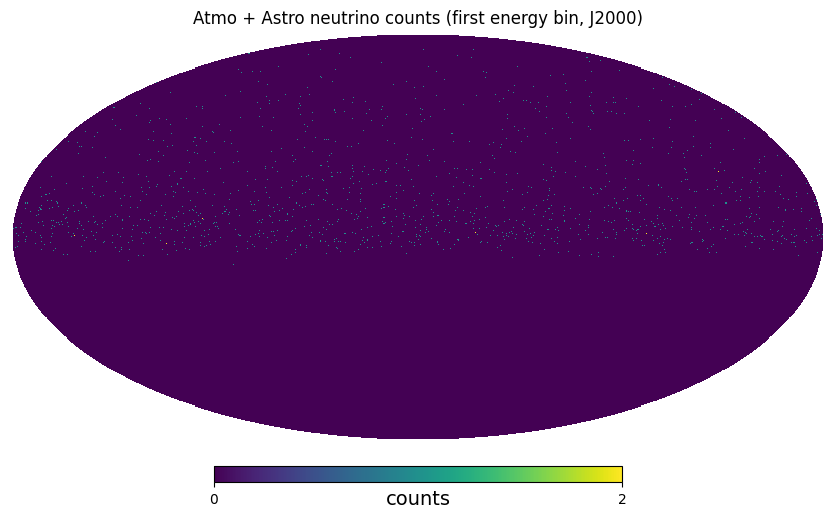

In [9]:

# ---------- save map to fits file ----------

m_counts = np.asarray(obs["maps_counts"][0])   # (npix,)

# Write to HEALPix FITS
fits_path = SIMS_ROOT / "atmo_plus_astro_counts_Ebin0.fits"

hp.write_map(
    str(fits_path),
    m_counts.astype(np.int64),        # counts -> integer
    nest=False,                       # set True if your map is in NESTED ordering
    dtype=np.int64,                   # ensure integer written to disk
    coord="C",                        # optional: label coordinate system in header (equatorial/J2000)
    column_names=["COUNTS"],          # optional: nicer column name than default
    column_units=["count"],           # optional units string
    extra_header=[("COMMENT", "Atmo+Astro neutrino counts (first energy bin)", "")],
    overwrite=True,
)

# Optional: round-trip check
m_back = hp.read_map(str(fits_path))

hp.mollview(
    m_back,
    title="Atmo + Astro neutrino counts (first energy bin, J2000)",
    unit="counts",
    flip="astro",
)


In [10]:
# ---------- Quick sanity checks ----------
print("Astro mean total (pre-PSF):", astro_means["maps_mean_prepsf"].sum())
print("Atmo  mean total (pre-PSF):", atmo_means["maps_mean_prepsf"].sum())
print("Astro sample total (first bin):", astro_counts["maps_counts"][0].sum())
print("Atmo  sample total (first bin):", atmo_counts["maps_counts"][0].sum())
print("Obs   sample total (first bin):",  obs["maps_counts"][0].sum())


Astro mean total (pre-PSF): 35.57917125597656
Atmo  mean total (pre-PSF): 19320.416932265733
Astro sample total (first bin): 13
Atmo  sample total (first bin): 17292
Obs   sample total (first bin): 17305


In [11]:
import numpy as np

def _print_bin_totals(label, means_prepsf, counts, bin_edges_GeV):
    means_prepsf = np.asarray(means_prepsf, dtype=float)
    counts = np.asarray(counts, dtype=np.int64)
    bin_edges_GeV = np.asarray(bin_edges_GeV, dtype=float)

    B = means_prepsf.shape[0]
    print(f"\n=== {label}: per-bin totals ===")
    for b in range(B):
        Elo, Ehi = bin_edges_GeV[b], bin_edges_GeV[b+1]
        mu_b = means_prepsf[b].sum()
        n_b  = counts[b].sum()
        # Poisson sanity: expect fluctuation scale ~ sqrt(mu)
        sig = np.sqrt(mu_b) if mu_b > 0 else 0.0
        z = (n_b - mu_b) / (sig + 1e-12)
        print(f"bin {b:2d} [{Elo:.2e}, {Ehi:.2e}] GeV : mean={mu_b:10.3f}  sample={n_b:7d}  (Δ/√μ = {z:+.2f})")

def _print_global_totals(label, means_prepsf, counts):
    mu = float(np.asarray(means_prepsf, dtype=float).sum())
    n  = int(np.asarray(counts, dtype=np.int64).sum())
    sig = np.sqrt(mu) if mu > 0 else 0.0
    z = (n - mu) / (sig + 1e-12)
    print(f"\n=== {label}: total over all bins+pixels ===")
    print(f"mean={mu:.3f}  sample={n:d}  (Δ/√μ = {z:+.2f})")

def _print_count_conservation(label, counts_in, counts_out):
    counts_in = np.asarray(counts_in, dtype=np.int64)
    counts_out = np.asarray(counts_out, dtype=np.int64)
    in_tot = counts_in.sum(axis=1)
    out_tot = counts_out.sum(axis=1)
    ok = np.all(in_tot == out_tot)
    print(f"\n=== {label}: PSF count conservation ===")
    print("per-bin totals in  :", in_tot.tolist())
    print("per-bin totals out :", out_tot.tolist())
    print("conserves counts?  :", bool(ok))

# ---------- Astro checks ----------
_print_bin_totals(
    "ASTRO",
    astro_means["maps_mean_prepsf"],
    astro_counts["maps_counts"],
    astro_means["bin_edges_GeV"],
)
_print_global_totals("ASTRO", astro_means["maps_mean_prepsf"], astro_counts["maps_counts"])

# ---------- Atmo checks ----------
_print_bin_totals(
    "ATMO",
    atmo_means["maps_mean_prepsf"],
    atmo_counts["maps_counts"],
    atmo_means["bin_edges_GeV"],
)
_print_global_totals("ATMO", atmo_means["maps_mean_prepsf"], atmo_counts["maps_counts"])

# ---------- Combined observation consistency ----------
print("\n=== OBS: additivity check (first bin) ===")
print("astro + atmo :", int(astro_counts["maps_counts"][0].sum() + atmo_counts["maps_counts"][0].sum()))
print("obs          :", int(obs["maps_counts"][0].sum()))





=== ASTRO: per-bin totals ===
bin  0 [1.00e+04, 3.98e+04] GeV : mean=    15.969  sample=     13  (Δ/√μ = -0.74)
bin  1 [3.98e+04, 1.58e+05] GeV : mean=    10.792  sample=     12  (Δ/√μ = +0.37)
bin  2 [1.58e+05, 6.31e+05] GeV : mean=     5.529  sample=      9  (Δ/√μ = +1.48)
bin  3 [6.31e+05, 2.51e+06] GeV : mean=     2.392  sample=      4  (Δ/√μ = +1.04)
bin  4 [2.51e+06, 1.00e+07] GeV : mean=     0.897  sample=      2  (Δ/√μ = +1.16)

=== ASTRO: total over all bins+pixels ===
mean=35.579  sample=40  (Δ/√μ = +0.74)

=== ATMO: per-bin totals ===
bin  0 [1.00e+04, 3.98e+04] GeV : mean= 17199.473  sample=  17292  (Δ/√μ = +0.71)
bin  1 [3.98e+04, 1.58e+05] GeV : mean=  1957.183  sample=   1991  (Δ/√μ = +0.76)
bin  2 [1.58e+05, 6.31e+05] GeV : mean=   153.689  sample=    144  (Δ/√μ = -0.78)
bin  3 [6.31e+05, 2.51e+06] GeV : mean=     9.572  sample=     15  (Δ/√μ = +1.75)
bin  4 [2.51e+06, 1.00e+07] GeV : mean=     0.501  sample=      0  (Δ/√μ = -0.71)

=== ATMO: total over all bins+pixels